In [1]:
import pandas as pd
df=pd.read_excel("/Users/ashwathakrishnan/Desktop/RENT_PREDICTIONS_APP/FINALISED DATASET FOR PROJECT.xlsx")
df

,LOCATION,ZONE,PROPERTY_TYPE,AGE_OF_PROPERTY,FLOOR,NO_OF_BEDROOMS,NO_OF_BATHROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA,MONTHLY_RENT
0,Adyar,south,Apartment,13,1,3,3,Furnished,No,Yes,No,1276,27000
1,Adyar,south,Independent House,18,3,2,2,Semi-Furnished,Yes,Yes,No,1064,64000
2,Adyar,south,Apartment,7,0,3,3,Semi-Furnished,Yes,Yes,No,1240,66000
3,Adyar,south,Apartment,8,1,1,1,Furnished,Yes,No,Yes,903,29000
4,Adyar,south,Apartment,1,1,2,2,Semi-Furnished,Yes,No,No,1213,48000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Vyasarpadi,north,Apartment,10,0,2,2,Semi-Furnished,Yes,No,No,1027,18000
2996,Vyasarpadi,north,Independent House,16,4,3,3,Semi-Furnished,No,Yes,No,1154,11000
2997,Vyasarpadi,north,Apartment,15,4,1,1,Semi-Furnished,Yes,No,No,764,8000
2998,Vyasarpadi,north,Apartment,14,3,3,3,Semi-Furnished,No,No,No,1268,12000


In [2]:
#---------------------------------------------    DATA UNDERSTANDING    --------------------------------------------------------

In [3]:
df.columns

Index(['LOCATION', 'ZONE', 'PROPERTY_TYPE', 'AGE_OF_PROPERTY', 'FLOOR',
       'NO_OF_BEDROOMS', 'NO_OF_BATHROOMS', 'FURNISHING_STATUS', 'PARKING',
       'LIFT ', 'PETS_ALLOWED', 'BUILT_AREA', 'MONTHLY_RENT '],
      dtype='object')

In [4]:
df.shape

(3000, 13)

In [5]:
df.describe()

,AGE_OF_PROPERTY,FLOOR,NO_OF_BEDROOMS,NO_OF_BATHROOMS,BUILT_AREA,MONTHLY_RENT
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,10.195333,2.423000,2.266000,2.252000,1127.869667,35646.666667
std,5.960343,1.360155,0.779389,0.784454,204.877375,25196.126101
min,0.000000,0.000000,1.000000,1.000000,356.000000,5000.000000
25%,5.000000,1.000000,2.000000,2.000000,995.000000,16000.000000
50%,10.000000,2.000000,2.000000,2.000000,1119.500000,29000.000000
75%,15.000000,3.000000,3.000000,3.000000,1262.250000,49000.000000
max,20.000000,5.000000,4.000000,4.000000,1707.000000,148000.000000


In [6]:
print("LOCATIONS : ",df['LOCATION'].unique())
print("--------------------------------------------------------------")
print("ZONES: ", df['ZONE'].unique())
print("ZONEWISE LOCATIONS:",df.groupby('ZONE')['LOCATION'].unique())
print("--------------------------------------------------------------")
print("PROPERTY TYPE: ", df['PROPERTY_TYPE'].unique())
print("--------------------------------------------------------------")
print("FURNISHING STATUS: ", df['FURNISHING_STATUS'].unique())
print("--------------------------------------------------------------")
print("PARKING: ", df['PARKING'].unique())
print("--------------------------------------------------------------")
print("LIFT : ", df['LIFT '].unique())
print("--------------------------------------------------------------")
print("PETS_ALLOWED: ", df['PETS_ALLOWED'].unique())
print("--------------------------------------------------------------")


LOCATIONS :  ['Adyar' 'Alandur' 'Anna Nagar' 'Ashok Nagar' 'Ayanavaram' 'Besant Nagar'
 'Egmore' 'Guindy' 'Kilpauk' 'KK Nagar' 'Kodungaiyur' 'Kolathur'
 'Koyambedu' 'Madhavaram' 'Mylapore' 'Nungambakkam' 'Pallavaram'
 'Perambur' 'Perungudi' 'Puzhal' 'Red Hills' 'Royapuram' 'Sholinganallur'
 'T Nagar' 'Tambaram' 'Thiruvanmiyur' 'Tondairpet' 'Vadapalani'
 'Velachery' 'Vyasarpadi']
--------------------------------------------------------------
ZONES:  ['south' 'central' 'north']
ZONEWISE LOCATIONS: ZONE
central    [Anna Nagar, Ashok Nagar, Egmore, Kilpauk, KK ...
north      [Ayanavaram, Kodungaiyur, Kolathur, Madhavaram...
south      [Adyar, Alandur, Besant Nagar, Guindy, Pallava...
Name: LOCATION, dtype: object
--------------------------------------------------------------
PROPERTY TYPE:  ['Apartment' 'Independent House']
--------------------------------------------------------------
FURNISHING STATUS:  ['Furnished' 'Semi-Furnished' 'Unfurnished']
----------------------------------------

In [7]:
#--------------------------------------------  DATA CLEANING  ----------------------------------------------------

In [8]:
df.isnull().sum()

LOCATION             0
ZONE                 0
PROPERTY_TYPE        0
AGE_OF_PROPERTY      0
FLOOR                0
NO_OF_BEDROOMS       0
NO_OF_BATHROOMS      0
FURNISHING_STATUS    0
PARKING              0
LIFT                 0
PETS_ALLOWED         0
BUILT_AREA           0
MONTHLY_RENT         0
dtype: int64

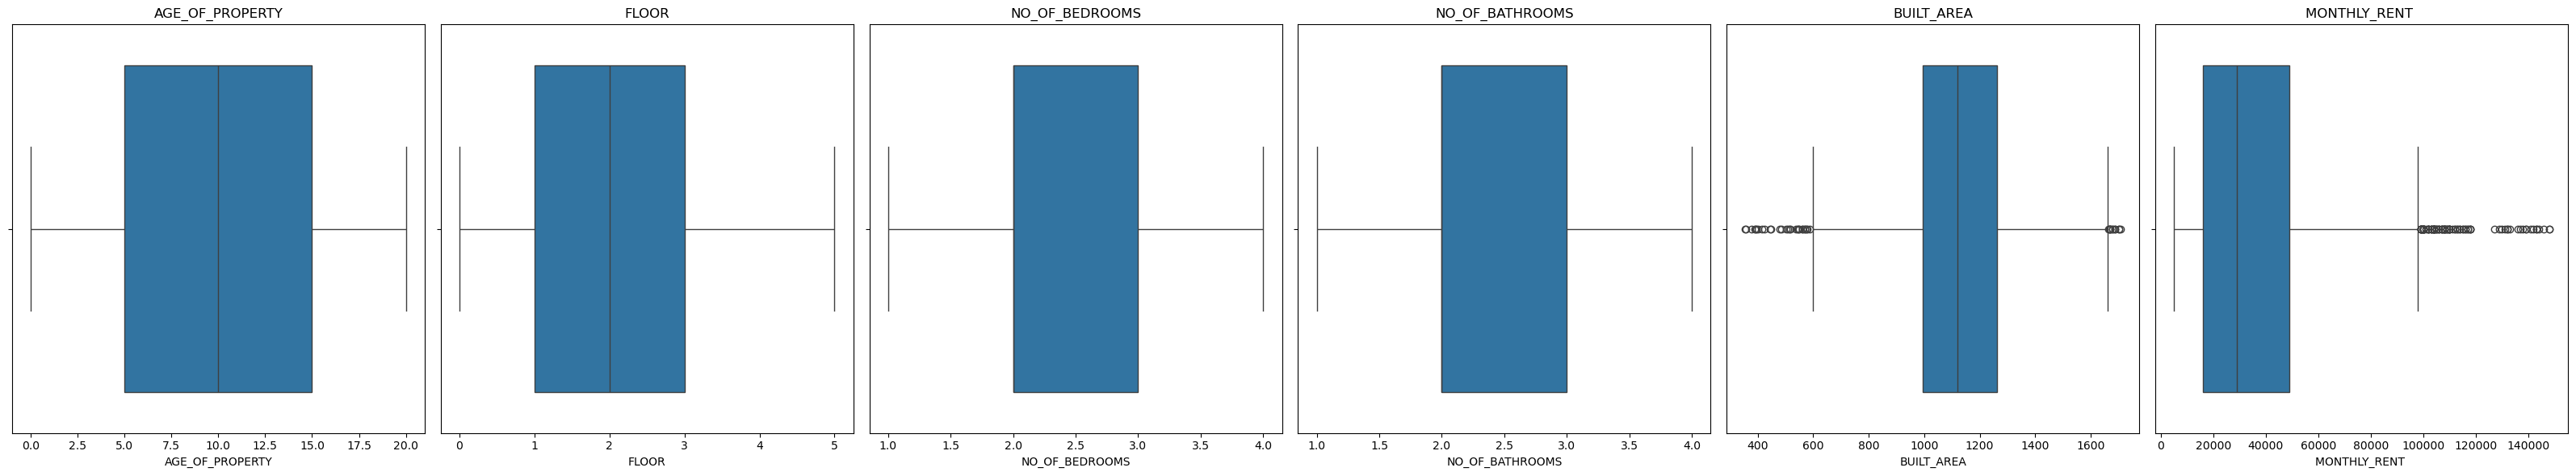

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 6, figsize=(32, 6))

sns.boxplot(x='AGE_OF_PROPERTY', data=df, ax=axes[0])
axes[0].set_title('AGE_OF_PROPERTY')

sns.boxplot(x='FLOOR', data=df, ax=axes[1])
axes[1].set_title('FLOOR')

sns.boxplot(x='NO_OF_BEDROOMS', data=df, ax=axes[2])
axes[2].set_title('NO_OF_BEDROOMS')
sns.boxplot(x='NO_OF_BATHROOMS', data=df, ax=axes[3])
axes[3].set_title('NO_OF_BATHROOMS')
sns.boxplot(x='BUILT_AREA', data=df, ax=axes[4])
axes[4].set_title('BUILT_AREA')
sns.boxplot(x='MONTHLY_RENT ', data=df, ax=axes[5])
axes[5].set_title('MONTHLY_RENT ')

plt.tight_layout()
plt.show()

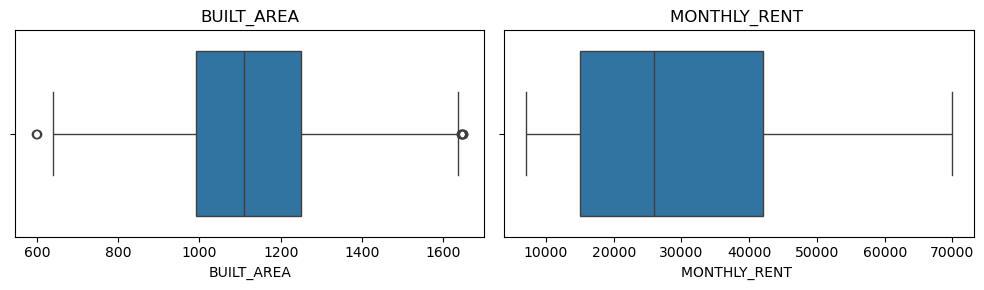

In [10]:
Q1 = df['BUILT_AREA'].quantile(0.25)
Q3 = df['BUILT_AREA'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['BUILT_AREA'] >= lower) & (df['BUILT_AREA'] <= upper)]

df = df[df['MONTHLY_RENT '] <= 70000]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.boxplot(x='BUILT_AREA', data=df, ax=axes[0])
axes[0].set_title('BUILT_AREA')

sns.boxplot(x='MONTHLY_RENT ', data=df, ax=axes[1])
axes[1].set_title('MONTHLY_RENT ')

plt.tight_layout()
plt.show()


In [11]:
df.shape

(2673, 13)

In [12]:
df["RENT_PER_SQFT"] = (df["MONTHLY_RENT "] / df["BUILT_AREA"]).round(0)
df

,LOCATION,ZONE,PROPERTY_TYPE,AGE_OF_PROPERTY,FLOOR,NO_OF_BEDROOMS,NO_OF_BATHROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA,MONTHLY_RENT,RENT_PER_SQFT
0,Adyar,south,Apartment,13,1,3,3,Furnished,No,Yes,No,1276,27000,21.0
1,Adyar,south,Independent House,18,3,2,2,Semi-Furnished,Yes,Yes,No,1064,64000,60.0
2,Adyar,south,Apartment,7,0,3,3,Semi-Furnished,Yes,Yes,No,1240,66000,53.0
3,Adyar,south,Apartment,8,1,1,1,Furnished,Yes,No,Yes,903,29000,32.0
4,Adyar,south,Apartment,1,1,2,2,Semi-Furnished,Yes,No,No,1213,48000,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Vyasarpadi,north,Apartment,10,0,2,2,Semi-Furnished,Yes,No,No,1027,18000,18.0
2996,Vyasarpadi,north,Independent House,16,4,3,3,Semi-Furnished,No,Yes,No,1154,11000,10.0
2997,Vyasarpadi,north,Apartment,15,4,1,1,Semi-Furnished,Yes,No,No,764,8000,10.0
2998,Vyasarpadi,north,Apartment,14,3,3,3,Semi-Furnished,No,No,No,1268,12000,9.0


In [13]:
#---------------------------------------------------------   EDA   --------------------------------------------------------------

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

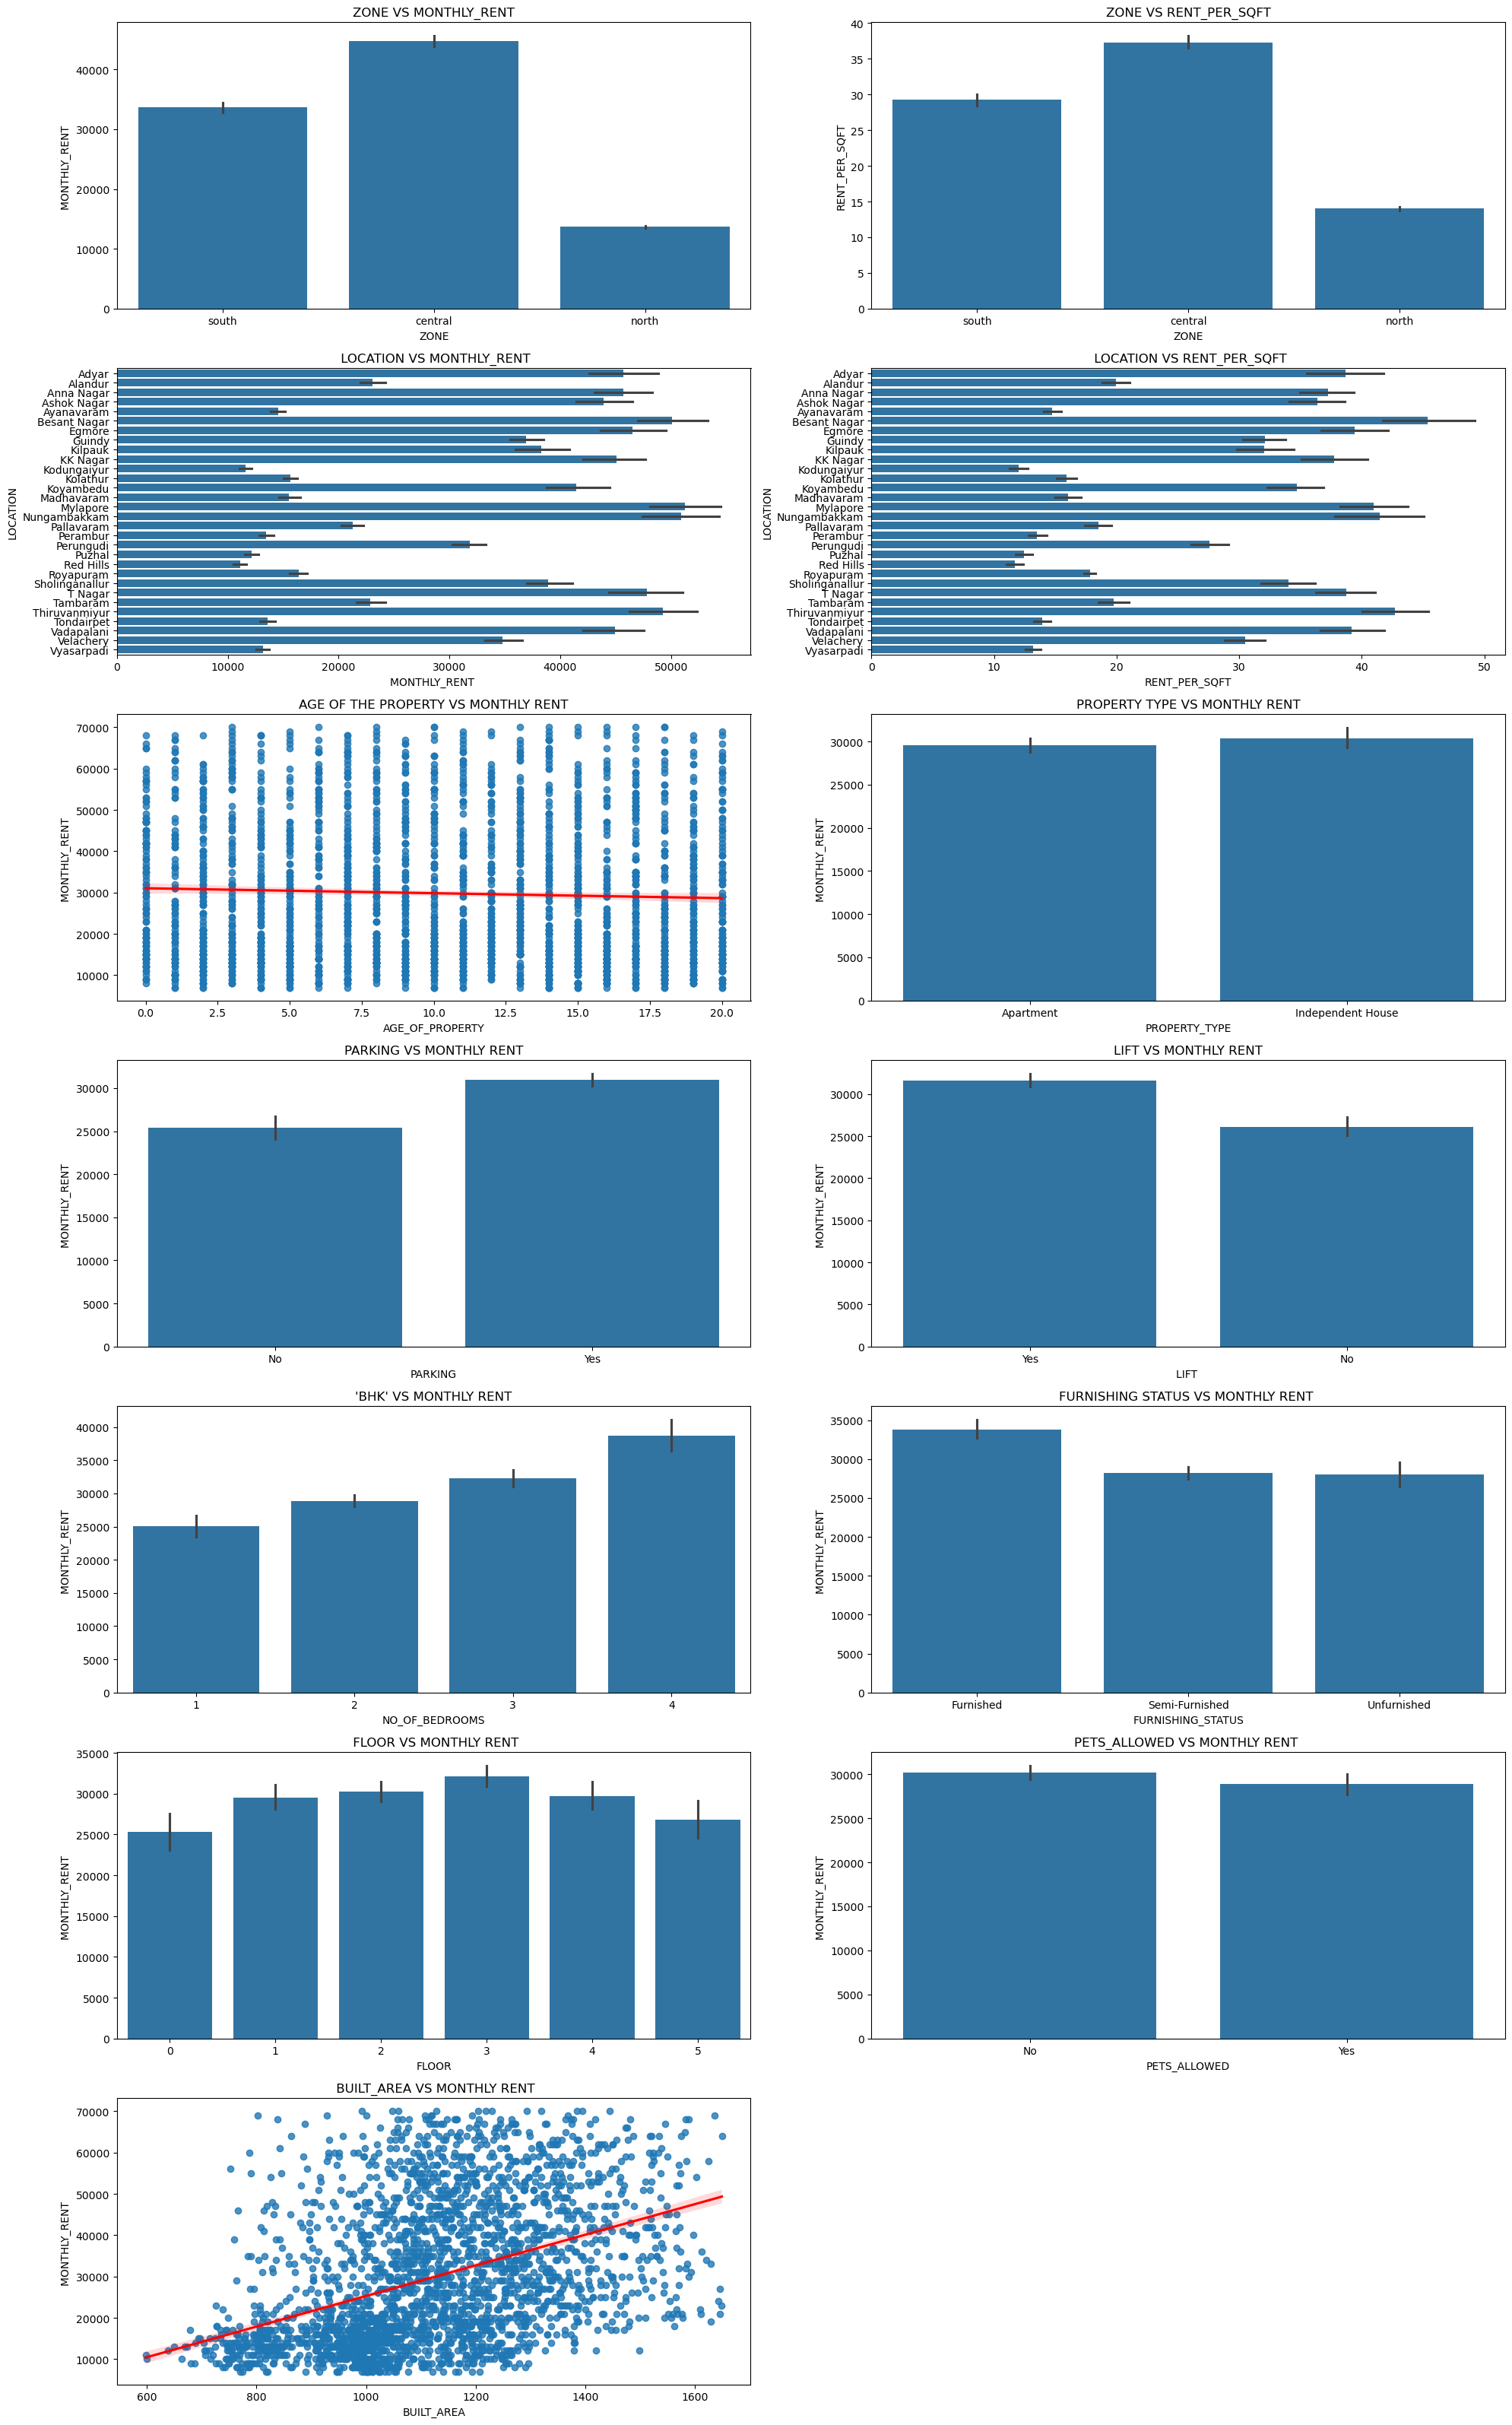

In [15]:
fig, axes = plt.subplots(7, 2, figsize=(20, 32))


sns.barplot(x="ZONE", y="MONTHLY_RENT ", data=df, ax=axes[0,0])
sns.barplot(x="ZONE", y="RENT_PER_SQFT", data=df, ax=axes[0,1])
axes[0,0].set_title("ZONE VS MONTHLY_RENT")
axes[0,1].set_title("ZONE VS RENT_PER_SQFT")


sns.barplot(x="MONTHLY_RENT ", y="LOCATION", data=df, ax=axes[1,0])
sns.barplot(x="RENT_PER_SQFT", y="LOCATION", data=df, ax=axes[1,1])
axes[1,0].set_title(" LOCATION VS MONTHLY_RENT")
axes[1,1].set_title(" LOCATION VS RENT_PER_SQFT")


sns.regplot(x="AGE_OF_PROPERTY", y="MONTHLY_RENT ", data=df, ax=axes[2,0],line_kws={"color": "red"})
sns.barplot(x="PROPERTY_TYPE", y="MONTHLY_RENT ", data=df, ax=axes[2,1])
axes[2,0].set_title("AGE OF THE PROPERTY VS MONTHLY RENT")
axes[2,1].set_title("PROPERTY TYPE VS MONTHLY RENT")

sns.barplot(x="PARKING", y="MONTHLY_RENT ", data=df, ax=axes[3,0])
sns.barplot(x="LIFT ", y="MONTHLY_RENT ", data=df, ax=axes[3,1])
axes[3,0].set_title("PARKING VS MONTHLY RENT")
axes[3,1].set_title("LIFT VS MONTHLY RENT")

sns.barplot(x="NO_OF_BEDROOMS", y="MONTHLY_RENT ", data=df, ax=axes[4,0])
sns.barplot(x="FURNISHING_STATUS", y="MONTHLY_RENT ", data=df, ax=axes[4,1])
axes[4,0].set_title("'BHK' VS MONTHLY RENT")
axes[4,1].set_title("FURNISHING STATUS VS MONTHLY RENT ")


sns.barplot(x="FLOOR", y="MONTHLY_RENT ", data=df, ax=axes[5,0])
sns.barplot(x="PETS_ALLOWED", y="MONTHLY_RENT ", data=df, ax=axes[5,1])
axes[5,0].set_title(" FLOOR VS MONTHLY RENT")
axes[5,1].set_title("PETS_ALLOWED VS MONTHLY RENT ")

sns.regplot(x="BUILT_AREA", y="MONTHLY_RENT ", data=df, ax=axes[6,0],line_kws={"color": "red"})
axes[6,0].set_title(" BUILT_AREA VS MONTHLY RENT")
axes[6,1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
KEY INSIGHTS FROM THE EDA:

1.Zone vs Monthly Rent:
Rental prices vary across zones, indicating that regional demand and locality 
significantly influence rental pricing.

2.Zone vs Rent per Sqft:
The rent per square foot differs across zones, suggesting variation in property 
value and housing demand between regions.

3.Location vs Monthly Rent:
Average rental prices vary considerably across locations, highlighting location 
as an important determinant of rent.

4.Location vs Rent per Sqft:
Rent per square foot shows noticeable variation among locations, reflecting 
differences in neighborhood value and property demand.

5.Age of Property vs Monthly Rent:
The relationship between property age and rent appears weak, suggesting that 
property age alone does not strongly influence rental prices.

6.Property Type vs Monthly Rent:
Different property types exhibit varying rental prices, indicating that 
the nature of the property plays a role in determining rent.

7.Parking vs Monthly Rent:
Properties with parking facilities tend to have higher average rent compared 
to those without parking.
    
8.Lift vs Monthly Rent:
Availability of lift facilities is associated with slightly higher rental prices, 
particularly in multi-storey residential properties.
    
9.BHK vs Monthly Rent:
Rental prices generally increase with the number of bedrooms, showing that larger
properties command higher rent.
    
10.Furnishing Status vs Monthly Rent:
Furnished properties tend to have higher rental prices compared to semi-furnished 
and unfurnished properties.
    
11.Monthly Rent Distribution:
The rent distribution appears right-skewed, indicating that most properties fall within 
moderate rent ranges while fewer premium properties exist at higher price levels.
    
12.Correlation Heatmap:
Most features show weak to moderate correlation with monthly rent, suggesting that 
rental pricing is influenced by a combination of multiple factors.



EDA Conclusion:

Exploratory Data Analysis indicates that rental prices are influenced by several factors 
including location, zone, property size, furnishing status, and amenities such as parking
and lift. While some features display clearer relationships with rent, others show 
weaker associations, suggesting that rental pricing depends on multiple interacting variables.

In [ ]:
#----------------------------------------------    DATA TRANSFORMATION    -----------------------------------------------------

In [16]:
import numpy as np
import pickle

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [17]:
features = ["ZONE", "LOCATION", "PROPERTY_TYPE","FLOOR", "NO_OF_BEDROOMS","FURNISHING_STATUS", "PARKING", "LIFT ","PETS_ALLOWED", "BUILT_AREA"]

target ="MONTHLY_RENT "

df = df[features + [target]].copy()


In [18]:
df

,ZONE,LOCATION,PROPERTY_TYPE,FLOOR,NO_OF_BEDROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA,MONTHLY_RENT
0,south,Adyar,Apartment,1,3,Furnished,No,Yes,No,1276,27000
1,south,Adyar,Independent House,3,2,Semi-Furnished,Yes,Yes,No,1064,64000
2,south,Adyar,Apartment,0,3,Semi-Furnished,Yes,Yes,No,1240,66000
3,south,Adyar,Apartment,1,1,Furnished,Yes,No,Yes,903,29000
4,south,Adyar,Apartment,1,2,Semi-Furnished,Yes,No,No,1213,48000
...,...,...,...,...,...,...,...,...,...,...,...
2995,north,Vyasarpadi,Apartment,0,2,Semi-Furnished,Yes,No,No,1027,18000
2996,north,Vyasarpadi,Independent House,4,3,Semi-Furnished,No,Yes,No,1154,11000
2997,north,Vyasarpadi,Apartment,4,1,Semi-Furnished,Yes,No,No,764,8000
2998,north,Vyasarpadi,Apartment,3,3,Semi-Furnished,No,No,No,1268,12000


In [19]:
encoders = {}

categorical_cols = ["ZONE", "LOCATION", "PROPERTY_TYPE","FURNISHING_STATUS", "PARKING", "LIFT ","PETS_ALLOWED"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

pickle.dump(encoders, open("encoders_final.pkl", "wb"))

In [20]:
df

,ZONE,LOCATION,PROPERTY_TYPE,FLOOR,NO_OF_BEDROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA,MONTHLY_RENT
0,2,0,0,1,3,0,0,1,0,1276,27000
1,2,0,1,3,2,1,1,1,0,1064,64000
2,2,0,0,0,3,1,1,1,0,1240,66000
3,2,0,0,1,1,0,1,0,1,903,29000
4,2,0,0,1,2,1,1,0,0,1213,48000
...,...,...,...,...,...,...,...,...,...,...,...
2995,1,29,0,0,2,1,1,0,0,1027,18000
2996,1,29,1,4,3,1,0,1,0,1154,11000
2997,1,29,0,4,1,1,1,0,0,764,8000
2998,1,29,0,3,3,1,0,0,0,1268,12000


In [21]:
x = df[features]
y = np.log1p(df[target])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
x_train

,ZONE,LOCATION,PROPERTY_TYPE,FLOOR,NO_OF_BEDROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA
1647,2,16,0,4,1,1,1,1,0,889
1376,1,13,1,3,1,2,1,0,0,818
2463,2,24,0,1,3,0,1,1,0,1260
100,2,1,1,2,1,0,1,1,1,987
2260,2,22,0,5,2,0,1,1,0,1124
...,...,...,...,...,...,...,...,...,...,...
1867,2,18,0,3,4,1,1,0,0,1437
1212,0,12,0,2,1,1,1,1,0,997
1247,0,12,0,3,2,1,1,1,0,1252
1427,0,14,0,5,2,0,1,0,0,1090


In [23]:
y_train

1647    10.165890
1376     9.952325
2463    10.434145
100     10.085851
2260    10.621352
          ...    
1867     9.798183
1212    10.985310
1247    10.275086
1427    10.463132
975     11.066654
Name: MONTHLY_RENT , Length: 2138, dtype: float64

In [24]:
x_test

,ZONE,LOCATION,PROPERTY_TYPE,FLOOR,NO_OF_BEDROOMS,FURNISHING_STATUS,PARKING,LIFT,PETS_ALLOWED,BUILT_AREA
575,2,5,1,4,2,1,1,1,0,1102
1330,1,13,0,4,1,0,0,1,0,856
1346,1,13,1,4,2,1,1,1,0,980
1971,1,19,0,0,2,2,1,1,1,1000
2060,1,20,0,1,2,1,1,1,0,971
...,...,...,...,...,...,...,...,...,...,...
901,0,8,0,2,2,1,1,0,0,1105
2091,1,20,1,4,2,1,0,1,1,1004
280,0,2,0,4,2,1,1,1,0,1215
1578,0,15,1,1,2,0,1,1,0,1241


In [25]:
#--------------------------------------------   MODEL BUILDING,MODEL EVALUATION -----------------------------------------

In [26]:
y_test

575     10.404293
1330     9.903538
1346     9.105091
1971     9.392745
2060     9.305741
          ...    
901     11.050906
2091     8.987322
280     10.545368
1578    10.819798
680     10.915107
Name: MONTHLY_RENT , Length: 535, dtype: float64

In [28]:
models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVM": SVR(),
    "XGBoost": XGBRegressor()
}

In [29]:
print("Baseline Model Performance:")
results = []
for name, model in models.items():
    model.fit(x_train, y_train)  
    pred_log = model.predict(x_test)
    pred = np.expm1(pred_log)
    y_actual = np.expm1(y_test)
    r2 = r2_score(y_actual, pred)
    mse = mean_squared_error(y_actual, pred)
    rmse = np.sqrt(mse)
    results.append({
        "Model": name,
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse
    })
results_df = pd.DataFrame(results)
results_df["R2"] = results_df["R2"].round(4)
results_df["MSE"] = results_df["MSE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)

print("\nBaseline Model Comparison:")
print(results_df)

Baseline Model Performance:

Baseline Model Comparison:
          Model      R2           MSE      RMSE
0        Linear  0.2792  2.030110e+08  14248.19
1  DecisionTree  0.3625  1.795645e+08  13400.17
2  RandomForest  0.6440  1.002623e+08  10013.10
3           SVM  0.1627  2.358370e+08  15356.98
4       XGBoost  0.6378  1.020057e+08  10099.79


In [30]:
#------------------------------------   HYPERTUNING PARAMETERS OF THE TOP 2 MODELS   -------------------------------

In [31]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [400, 500, 600, 800, 900],
    "max_depth": [10,15,20,25],
    "min_samples_split": [2,5,10,15],
    "min_samples_leaf": [9,10,11,12],
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(estimator=rf,param_distributions=rf_params,n_iter=40,cv=3,scoring="r2",random_state=42,n_jobs=-1)

rf_random.fit(x_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'max_depth': [10, 15, 20, 25],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [9, 10, 11, 12],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': [400, 500, 600, 800,
                                                         900]},
                   random_state=42, scoring='r2')

In [32]:
xgb = XGBRegressor(random_state=42)

xgb_params = {"n_estimators": [100, 200, 300,400],"learning_rate": [0.01, 0.03, 0.05, 0.07],"max_depth": [6, 7, 8, 9], "subsample": [0.7, 0.8, 1],
              "colsample_bytree": [0.7, 0.8, 1],
              "gamma": [0, 0.1, 0.3],
              "reg_alpha": [0, 0.1, 1],
              "reg_lambda": [1, 1.5, 2]
            }

xgb_random = RandomizedSearchCV(estimator=xgb,param_distributions=xgb_params,n_iter=50,cv=3,scoring="r2",random_state=42,n_jobs=-1)

xgb_random.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07],
                                        'max_depth': [6, 7, 8, 9],
                                        'n_estimators': [100, 200, 300, 400],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.7, 0.8, 1]},
                   random_state=42, scoring='r2')

In [33]:
#-----------------------------------------    MODEL SELECTION, MODEL SAVING   ---------------------------------------------

In [34]:
from sklearn.metrics import r2_score, mean_squared_error

rf_best = rf_random.best_estimator_
xgb_best = xgb_random.best_estimator_


rf_pred = np.expm1(rf_best.predict(x_test))
xgb_pred = np.expm1(xgb_best.predict(x_test))

y_actual = np.expm1(y_test)


rf_r2 = r2_score(y_actual, rf_pred)
rf_mse = mean_squared_error(y_actual, rf_pred)
rf_rmse = np.sqrt(rf_mse)

xgb_r2 = r2_score(y_actual, xgb_pred)
xgb_mse = mean_squared_error(y_actual, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)


results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "R2": [rf_r2, xgb_r2],
    "MSE": [rf_mse, xgb_mse],
    "RMSE": [rf_rmse, xgb_rmse]
})

results_df["R2"] = results_df["R2"].round(4)
results_df["MSE"] = results_df["MSE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)

print(results_df)

           Model      R2          MSE     RMSE
0  Random Forest  0.7068  82571521.38  9086.89
1        XGBoost  0.6980  85075172.98  9223.62


In [35]:
best_model = rf_best if rf_rmse < xgb_rmse else xgb_best
print(best_model)


RandomForestRegressor(max_depth=10, max_features=None, min_samples_leaf=11,
                      min_samples_split=15, n_estimators=400, random_state=42)


In [36]:
pickle.dump(best_model, open("model_final.pkl", "wb"))
